In [1]:
import iris
import iris.plot as iplt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm
import statsmodels.formula.api as smf

### Get 5km hydraulic conductivity data

In [2]:
hc_5km = iris.load(f"../../Data/HydraulicConductivity/GB_5km.nc")[0]

In [3]:
# Define class boundaries
q1 = 0.1
q2 = 0.15 
q3 = 0.3
q4 = 0.6
q5 = 0.9
q6 = 2
q7 = 3


# Define your quantile breakpoints as a list (add/remove as many as you like)
quantiles = [0.1, 0.3, 0.6, 0.9, 1, 2, 3]  
q0 = 0  # lower bound, adjust if needed

### Check plotting with boundaries

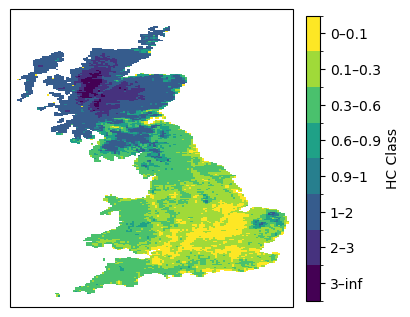

In [4]:
n_classes = len(quantiles) + 1

# Auto-generate labels from bin edges (reversed to match flipped class order)
edges = [q0] + quantiles + [np.inf]
class_labels = [f"{edges[i]}–{edges[i+1]}" for i in range(len(edges)-1)][::-1]

# Auto-generate colors from a colormap, sampled evenly across n_classes
base_cmap = plt.get_cmap('viridis')  # swap for 'RdYlBu_r', 'plasma', etc. as preferred
colors = [base_cmap(i) for i in np.linspace(0, 1, n_classes)]

# Get data
hk_vals = hc_5km.data
if np.ma.is_masked(hk_vals):
    hk_vals = hk_vals.filled(np.nan)

# Convert data to classes (flip the order), bins built from the quantiles list
bins = [q0] + quantiles
classified = (n_classes + 1) - np.digitize(hk_vals, bins=bins)
classified = classified.astype(float)
classified[np.isnan(hk_vals)] = np.nan

# Assign back to cube
hc_class_cube = hc_5km.copy()
hc_class_cube.data = classified

fig = plt.figure(figsize=(4, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 2, 49.5, 60], crs=ccrs.PlateCarree())
cmap = ListedColormap(colors)
bounds = np.arange(0.5, n_classes + 1.5, 1)
norm = BoundaryNorm(bounds, cmap.N)
mesh = iplt.pcolormesh(hc_class_cube, axes=ax, cmap=cmap, norm=norm)
ticks = np.arange(1, n_classes + 1)
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=ticks)
cbar.ax.set_yticklabels(class_labels)
cbar.set_label('HC Class')

### Check zero fraction in each class

In [5]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df['length'] = rainfall_events_all_df['times'].apply(len)

In [6]:
bins = [-float('inf')] + quantiles + [float('inf')]
n_classes = len(bins) - 1


import string
labels=class_labels[::-1]
rainfall_events_all_df['HC_status_2'] = pd.cut( rainfall_events_all_df['hc_at_peak'], bins=bins, labels=labels, 
                                               right=False, include_lowest=True)

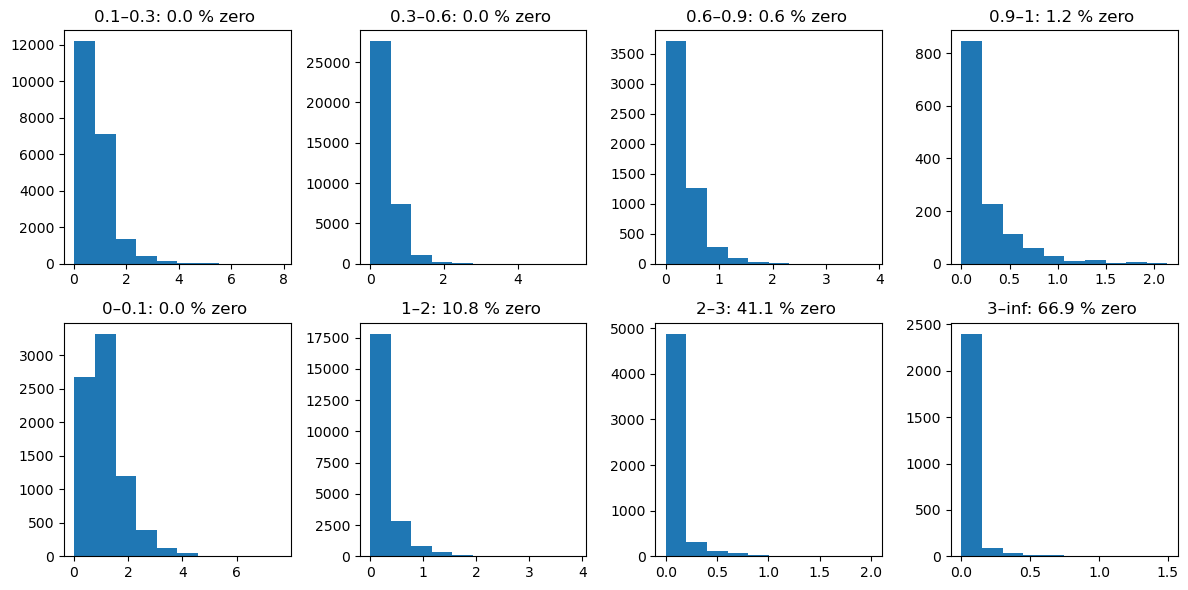

In [7]:
df= rainfall_events_all_df
fig, axs =plt.subplots(ncols=4, nrows = 2, figsize=(12,6))
axs=axs.flatten()
for i, cls in enumerate(sorted(df['HC_status_2'].unique())):
    sub = df[df['HC_status_2'] == cls]
    zero_frac = len(sub[sub['10cm_area'] == 0])/len(sub) * 100
    axs[i].hist(sub['10cm_area'], bins=10)
    axs[i].set_title(f"{cls}: {round(zero_frac,1)} % zero ")
fig.tight_layout()

### Check relationships between rainfall and flooding in each class

In [8]:
intensity_vars = ['max_precip', 'total_acc']
shape_vars = ['peak_position_ratio', 'd50', 'gini', 'time_based_std', 'dry_ratio', 'max_quartile_index']
neighbourhood_vars = ['cluster_flood_10_area_t80']
antecedent_vars = ['mean_sm_2_before_event']
length_vars = ['length']
candidate_vars = length_vars + antecedent_vars + neighbourhood_vars + shape_vars + intensity_vars

In [9]:
print(len(rainfall_events_all_df))
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['10cm_area']>0].copy()
print(len(rainfall_events_all_df))

102046
95686


In [10]:
df= rainfall_events_all_df
def run_stage(sub, predictors, label):
    formula = 'Q("10cm_area") ~ ' + ' + '.join(predictors)
    model = smf.ols(formula, data=sub).fit()
    # print(model.summary())
    print(f"  {label}: R² = {model.rsquared:.3f}")
    return model

results = {}
for cls in sorted(df['HC_status_2'].unique()):
    sub = df[df['HC_status_2'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    print(f"\n--- HC class {cls} (n={len(sub)}) ---")
    
    m1 = run_stage(sub, intensity_vars , "Baseline (intensity+acc)")
    m2 = run_stage(sub, intensity_vars + antecedent_vars, "+antecedent")
    m3 = run_stage(sub, intensity_vars + antecedent_vars + neighbourhood_vars, "+ neighbourhood")
    m4 = run_stage(sub, intensity_vars + antecedent_vars + neighbourhood_vars + shape_vars, "+ shape/temporal-loading")
    
    results[cls] = {'baseline': m1, 'shape': m2, 'length': m3, 'full': m4}


--- HC class 0.1–0.3 (n=21240) ---
  Baseline (intensity+acc): R² = 0.257
  +antecedent: R² = 0.260
  + neighbourhood: R² = 0.547
  + shape/temporal-loading: R² = 0.550

--- HC class 0.3–0.6 (n=36386) ---
  Baseline (intensity+acc): R² = 0.220
  +antecedent: R² = 0.229
  + neighbourhood: R² = 0.542
  + shape/temporal-loading: R² = 0.547

--- HC class 0.6–0.9 (n=5364) ---
  Baseline (intensity+acc): R² = 0.312
  +antecedent: R² = 0.364
  + neighbourhood: R² = 0.663
  + shape/temporal-loading: R² = 0.671

--- HC class 0.9–1 (n=1288) ---
  Baseline (intensity+acc): R² = 0.472
  +antecedent: R² = 0.474
  + neighbourhood: R² = 0.753
  + shape/temporal-loading: R² = 0.762

--- HC class 0–0.1 (n=7793) ---
  Baseline (intensity+acc): R² = 0.247
  +antecedent: R² = 0.249
  + neighbourhood: R² = 0.503
  + shape/temporal-loading: R² = 0.508

--- HC class 1–2 (n=19555) ---
  Baseline (intensity+acc): R² = 0.503
  +antecedent: R² = 0.503
  + neighbourhood: R² = 0.811
  + shape/temporal-loading: R²

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

for cls in sorted(df['HC_status_2'].unique()):
    sub = df[df['HC_status_2'] == cls].dropna(subset=candidate_vars + ['10cm_area'])
    X = sub[candidate_vars]
    y = sub['10cm_area']
    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
    scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    print(f"{cls}: RF CV R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

0.1–0.3: RF CV R² = 0.651 (+/- 0.035)
0.3–0.6: RF CV R² = 0.638 (+/- 0.057)
0.6–0.9: RF CV R² = 0.743 (+/- 0.043)
0.9–1: RF CV R² = 0.825 (+/- 0.020)
0–0.1: RF CV R² = 0.663 (+/- 0.044)
1–2: RF CV R² = 0.874 (+/- 0.025)
2–3: RF CV R² = 0.886 (+/- 0.037)
3–inf: RF CV R² = 0.908 (+/- 0.033)


In [14]:
from sklearn.inspection import PartialDependenceDisplay

rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1)
X = df[candidate_vars + ['hc_at_peak']].dropna()
y = df.loc[X.index, '10cm_area']
rf.fit(X, y)

PartialDependenceDisplay.from_estimator(
    rf, X,
    features=['hc_at_peak',
              ('hc_at_peak', '10cm_area')],  # 2D interaction plot
    kind='average'
)

ValueError: Feature '10cm_area' not in feature_names